
# BTC / ETH 4-hour dataset report  


- Data loading and alignment of BTC and ETH 4-hour returns
- Distribution diagnostics: summary statistics, Gaussian comparison, Q-Q plots, tail probabilities
- Dependence diagnostics: correlation, copula-style view, tail co-movement
- Regression-based factor view (Assignment 3 empirical part)
- PCA-based common-factor view (Assignment 3 empirical part)
- Statistical decision / estimation framing for this dataset 
- A Black-Litterman illustration using the estimated BTC/ETH covariance 

Throughout the notebook, the working dataset is the aligned return matrix

$$
R_t =
\begin{pmatrix}
R_t^{BTC} \\
R_t^{ETH}
\end{pmatrix},
$$

where each component is the 4-hour log return from the uploaded merged CSV files.


## 1. Data loading and alignment

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional scientific tools used later in the notebook
from scipy.stats import skew, kurtosis, gaussian_kde, norm, probplot, spearmanr, kendalltau, rankdata
from scipy.linalg import eigh
from scipy.stats import chi2
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.dpi"] = 120

def find_file(patterns):
    """
    Search for the BTC / ETH CSV files robustly.

    The notebook checks:
    1. the current working directory,
    2. all subfolders of the current working directory,
    3. /mnt/data (useful in ChatGPT / uploaded-file environments).

    It accepts names like:
    - BTCUSDT_4h_merged.csv
    - BTCUSDT_4h_merged(2).csv
    - BTCUSDT_4h_merged_anything.csv
    """
    candidate_roots = [Path("."), Path("/mnt/data")]
    matches = []

    for root in candidate_roots:
        if not root.exists():
            continue
        for pattern in patterns:
            # direct children
            matches.extend(root.glob(pattern))
            # recursive search in subfolders
            matches.extend(root.rglob(pattern))

    # remove duplicates while preserving order
    seen = set()
    cleaned = []
    for m in matches:
        rp = str(m.resolve()) if m.exists() else str(m)
        if rp not in seen:
            seen.add(rp)
            cleaned.append(m)

    if cleaned:
        # choose the most recently modified file if possible
        try:
            cleaned = sorted(cleaned, key=lambda p: p.stat().st_mtime)
        except Exception:
            cleaned = sorted(cleaned)
        chosen = cleaned[-1]
        print(f"Using file: {chosen}")
        return chosen

    cwd = Path.cwd()
    raise FileNotFoundError(
        "Could not find any file matching: "
        f"{patterns}\n\n"
        f"Current working directory: {cwd}\n"
        "Please either:\n"
        "1) put the CSV files in the same folder as this notebook, or\n"
        "2) put them in a subfolder under the notebook directory, or\n"
        "3) edit btc_path / eth_path manually to the exact file path."
    )

btc_path = find_file(["BTCUSDT_4h_merged*.csv", "*BTCUSDT_4h_merged*.csv"])
eth_path = find_file(["ETHUSDT_4h_merged*.csv", "*ETHUSDT_4h_merged*.csv"])

btc = pd.read_csv(btc_path, parse_dates=["open_time"])
eth = pd.read_csv(eth_path, parse_dates=["open_time"])

df = (
    btc[["open_time", "return_1"]].rename(columns={"return_1": "btc"})
    .merge(
        eth[["open_time", "return_1"]].rename(columns={"return_1": "eth"}),
        on="open_time",
        how="inner",
    )
    .dropna()
    .sort_values("open_time")
    .reset_index(drop=True)
)

dataset_overview = pd.DataFrame({
    "file": [str(btc_path), str(eth_path)],
    "rows in source file": [len(btc), len(eth)],
}, index=["BTC source", "ETH source"])

display(dataset_overview)
display(df.head())
print("Aligned sample size:", len(df))
print("Sample start:", df["open_time"].min())
print("Sample end  :", df["open_time"].max())

from types import SimpleNamespace

def _as_array_1d(a):
    arr = np.asarray(a, dtype=float)
    return arr.reshape(-1)

def add_constant(x):
    x = _as_array_1d(x)
    return np.column_stack([np.ones(len(x)), x])

def _newey_west_cov(X, resid, maxlags=6):
    X = np.asarray(X, dtype=float)
    resid = _as_array_1d(resid)
    n, k = X.shape
    XtX_inv = np.linalg.inv(X.T @ X)
    S = np.zeros((k, k), dtype=float)

    for t in range(n):
        xt = X[t:t+1].T
        S += resid[t] ** 2 * (xt @ xt.T)

    for lag in range(1, maxlags + 1):
        weight = 1.0 - lag / (maxlags + 1.0)
        Gamma = np.zeros((k, k), dtype=float)
        for t in range(lag, n):
            xt = X[t:t+1].T
            xt_lag = X[t-lag:t-lag+1].T
            Gamma += resid[t] * resid[t - lag] * (xt @ xt_lag.T)
        S += weight * (Gamma + Gamma.T)

    return XtX_inv @ S @ XtX_inv

def ols_fit_with_optional_hac(y, x, hac_lags=6, regressor_name="btc"):
    y = _as_array_1d(y)
    x = _as_array_1d(x)
    X = add_constant(x)
    n, k = X.shape

    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ (X.T @ y)
    fitted = X @ beta
    resid = y - fitted

    sigma2 = (resid @ resid) / (n - k)
    cov_ols = sigma2 * XtX_inv
    se_ols = np.sqrt(np.diag(cov_ols))

    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum(resid ** 2)
    rsquared = 1.0 - ss_res / ss_tot

    cov_hac = _newey_west_cov(X, resid, maxlags=hac_lags)
    se_hac = np.sqrt(np.diag(cov_hac))
    z_hac = beta / se_hac
    p_hac = 2.0 * (1.0 - norm.cdf(np.abs(z_hac)))

    index = ["const", regressor_name]

    ols = SimpleNamespace(
        params=pd.Series(beta, index=index),
        bse=pd.Series(se_ols, index=index),
        resid=pd.Series(resid),
        fittedvalues=pd.Series(fitted),
        rsquared=float(rsquared),
    )

    ols_hac = SimpleNamespace(
        bse=pd.Series(se_hac, index=index),
        tvalues=pd.Series(z_hac, index=index),
        pvalues=pd.Series(p_hac, index=index),
    )

    return ols, ols_hac


Using file: BTCUSDT_4h_merged.csv
Using file: ETHUSDT_4h_merged.csv


,file,rows in source file
BTC source,BTCUSDT_4h_merged.csv,4867
ETH source,ETHUSDT_4h_merged.csv,4867


,open_time,btc,eth
0,2024-01-01 04:00:00+00:00,0.003819,0.004765
1,2024-01-01 08:00:00+00:00,0.004643,0.008629
2,2024-01-01 12:00:00+00:00,0.002173,0.004429
3,2024-01-01 16:00:00+00:00,0.017032,0.009699
4,2024-01-01 20:00:00+00:00,0.015088,0.006304


Aligned sample size: 4866
Sample start: 2024-01-01 04:00:00+00:00
Sample end  : 2026-03-22 00:00:00+00:00


### How to read the output

- The first table tells us **which files were used** and how many rows each raw file contains.
- The second table shows the **first few aligned observations**.
- The printed lines confirm the **usable sample size** and the **time coverage**.

### Interpretation for the current dataset

The aligned dataset contains **4,866 paired 4-hour observations**, spanning approximately **2024-01-01 to 2026-03-22**.  
This is large enough for stable empirical diagnostics such as density comparison, regression, and PCA.


## 2. Summary statistics and first stylized facts

In [2]:

summary = pd.DataFrame({
    "mean": [df["btc"].mean(), df["eth"].mean()],
    "std": [df["btc"].std(ddof=1), df["eth"].std(ddof=1)],
    "skewness": [skew(df["btc"], bias=False), skew(df["eth"], bias=False)],
    "excess_kurtosis": [kurtosis(df["btc"], fisher=True, bias=False), kurtosis(df["eth"], fisher=True, bias=False)],
    "min": [df["btc"].min(), df["eth"].min()],
    "max": [df["btc"].max(), df["eth"].max()],
}, index=["BTC", "ETH"])

summary


,mean,std,skewness,excess_kurtosis,min,max
BTC,0.000101,0.010338,-0.169604,6.176280,-0.083711,0.069280
ETH,-0.000015,0.014580,-0.520019,9.154821,-0.150715,0.109062



### Detailed explanation of the table

This table gives the most basic statistical summary of the 4-hour return series.

- **Mean** measures the average 4-hour return.
- **Standard deviation** measures volatility.
- **Skewness** measures asymmetry.  
  Negative values mean the left tail is heavier than the right tail.
- **Excess kurtosis** measures tail-heaviness relative to a Gaussian distribution.  
  A Gaussian has excess kurtosis equal to **0**.
- **Min / Max** show the largest realized negative and positive 4-hour moves.

### What the current output says

- BTC mean is about **0.000101**, and ETH mean is about **-0.000015**.  
  Both are very close to zero at the 4-hour horizon, which is normal for high-frequency return data.
- BTC volatility is about **1.0338%**, while ETH volatility is about **1.4580%**.  
  So ETH is materially more volatile than BTC.
- BTC skewness is **-0.170**, and ETH skewness is **-0.520**.  
  Both are negative, and ETH is more negatively skewed, meaning downside moves are more pronounced for ETH.
- BTC excess kurtosis is **6.176**, and ETH excess kurtosis is **9.155**.  
  Both are far above 0, so both return series are much more heavy-tailed than a Gaussian benchmark.

### Immediate empirical conclusion

The dataset already exhibits the classic **stylized facts of financial returns**:

1. near-zero short-horizon mean,  
2. volatility much larger than mean,  
3. negative skewness, and  
4. heavy tails.  

Among the two assets, **ETH looks riskier and more non-Gaussian** than BTC.


## 3. Density comparison with a matching Gaussian

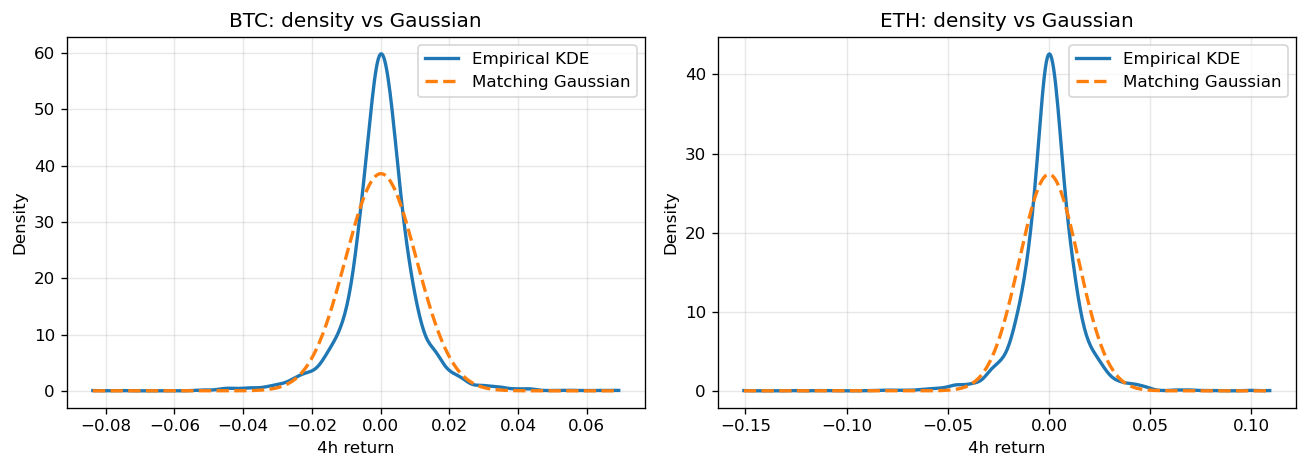

In [3]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, name in zip(axes, ["btc", "eth"], ["BTC", "ETH"]):
    x = df[col].to_numpy()
    kde = gaussian_kde(x)
    grid = np.linspace(x.min(), x.max(), 500)
    mu = x.mean()
    sd = x.std(ddof=1)

    ax.plot(grid, kde(grid), lw=2, label="Empirical KDE")
    ax.plot(grid, norm.pdf(grid, loc=mu, scale=sd), lw=2, ls="--", label="Matching Gaussian")
    ax.set_title(f"{name}: density vs Gaussian")
    ax.set_xlabel("4h return")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### Why this plot is useful

A mean and variance alone do **not** tell us whether returns are approximately Gaussian.  
This plot compares the empirical density with a Gaussian distribution having the **same mean and standard deviation**.

### How to read the plot

- If the empirical blue curve almost overlaps the dashed Gaussian curve, then the distribution is close to normal.
- If the empirical curve is **sharper at the center** and **fatter in the tails**, then the series is **leptokurtic** (heavy-tailed).

### What the current output shows

For both BTC and ETH:

- the center peak is **higher and narrower** than the Gaussian benchmark,
- the tails remain **visibly thicker** than the Gaussian tails.

So the returns are **not well described by a normal distribution**, even after matching mean and variance.

### Practical meaning

This matters because many textbook portfolio models begin with normality assumptions.  
Your dataset shows that for 4-hour crypto returns, those assumptions are only rough approximations.  
Any later risk analysis should remember that **extreme moves occur more often than a Gaussian model would predict**.


## 4. Tail diagnostics

In [4]:

def tail_probs(x):
    z = (x - x.mean()) / x.std(ddof=1)
    return pd.Series({
        "P(|Z|>2)": np.mean(np.abs(z) > 2),
        "P(|Z|>3)": np.mean(np.abs(z) > 3),
        "P(Z<-2)": np.mean(z < -2),
        "P(Z>2)": np.mean(z > 2),
    })

tail_table = pd.concat({
    "BTC": tail_probs(df["btc"].to_numpy()),
    "ETH": tail_probs(df["eth"].to_numpy()),
}, axis=1)

gaussian_reference = pd.Series({
    "P(|Z|>2)": 2 * (1 - norm.cdf(2)),
    "P(|Z|>3)": 2 * (1 - norm.cdf(3)),
    "P(Z<-2)": norm.cdf(-2),
    "P(Z>2)": 1 - norm.cdf(2),
}, name="Gaussian benchmark")

display(tail_table)
display(gaussian_reference.to_frame())


,BTC,ETH
P(|Z|>2),0.057337,0.051993
P(|Z|>3),0.018290,0.017674
P(Z<-2),0.032059,0.028360
P(Z>2),0.025277,0.023633


,Gaussian benchmark
P(|Z|>2),0.04550
P(|Z|>3),0.00270
P(Z<-2),0.02275
P(Z>2),0.02275



### Detailed explanation of the output

Here, each return series is standardized into a z-score:

$$
Z = \frac{X-\bar X}{s}.
$$

Then we ask how often the standardized return lies beyond 2 or 3 standard deviations.

### What the current numbers mean

For BTC:

- $P(|Z|>2)$ is about **5.7337%**
- $P(|Z|>3)$ is about **1.8290%**

For ETH:

- $P(|Z|>2)$ is about **5.1993%**
- $P(|Z|>3)$ is about **1.7674%**

Under a true Gaussian distribution, the corresponding reference probabilities are approximately:

- $P(|Z|>2) \approx 4.55\%$
- $P(|Z|>3) \approx 0.27\%$

### Interpretation

- The 2-sigma events are already somewhat more frequent than Gaussian.
- The 3-sigma events are **dramatically more frequent** than Gaussian:
  - BTC: about **6.8 times** the Gaussian benchmark
  - ETH: about **6.5 times** the Gaussian benchmark

This is a very strong tail-risk signal.

### Why this matters

The result supports the claim that **crypto returns are tail-heavy**, and it justifies:
- using robust diagnostics,
- being careful with normal-based inference,
- and discussing downside risk explicitly instead of relying only on variance.


## 5. Q-Q plots against the normal reference

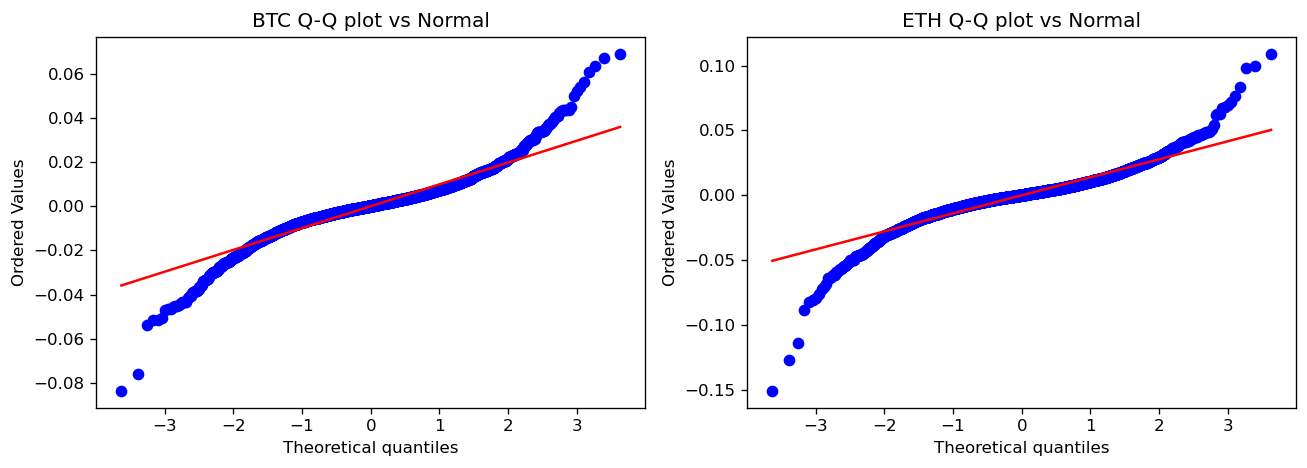

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

probplot(df["btc"], dist="norm", plot=axes[0])
axes[0].set_title("BTC Q-Q plot vs Normal")

probplot(df["eth"], dist="norm", plot=axes[1])
axes[1].set_title("ETH Q-Q plot vs Normal")

plt.tight_layout()
plt.show()



### Why Q-Q plots are included

The density plot gives a visual global comparison, but the Q-Q plot is especially good for showing **tail departures**.

### How to read the Q-Q plot

- If the data were Gaussian, the points would lie close to the straight reference line.
- If the lower tail bends below the line and the upper tail bends above it, the series has **fatter tails than normal**.

### What the current output says

Both BTC and ETH show strong curvature in both tails:

- the left tail falls well below the line,
- the right tail rises well above the line.

ETH's deviations are stronger, which matches the earlier evidence that ETH is more heavy-tailed and more negatively skewed.

### Conclusion from this section

The Q-Q evidence confirms that the non-Gaussian behavior is not a small effect.  
It is a structural feature of the dataset.


## 6. Dependence structure between BTC and ETH

In [6]:

pearson = df["btc"].corr(df["eth"])
spearman = spearmanr(df["btc"], df["eth"]).statistic
kendall = kendalltau(df["btc"], df["eth"]).statistic

u_btc = rankdata(df["btc"], method="average") / (len(df) + 1.0)
u_eth = rankdata(df["eth"], method="average") / (len(df) + 1.0)

z_btc = norm.ppf(u_btc)
z_eth = norm.ppf(u_eth)
gaussian_copula_rho = np.corrcoef(z_btc, z_eth)[0, 1]

dep_summary = pd.DataFrame({
    "Measure": ["Pearson", "Spearman", "Kendall tau", "Gaussian-copula rho"],
    "Value": [pearson, spearman, kendall, gaussian_copula_rho],
})

dep_summary


,Measure,Value
0,Pearson,0.811943
1,Spearman,0.783401
2,Kendall tau,0.604509
3,Gaussian-copula rho,0.804052


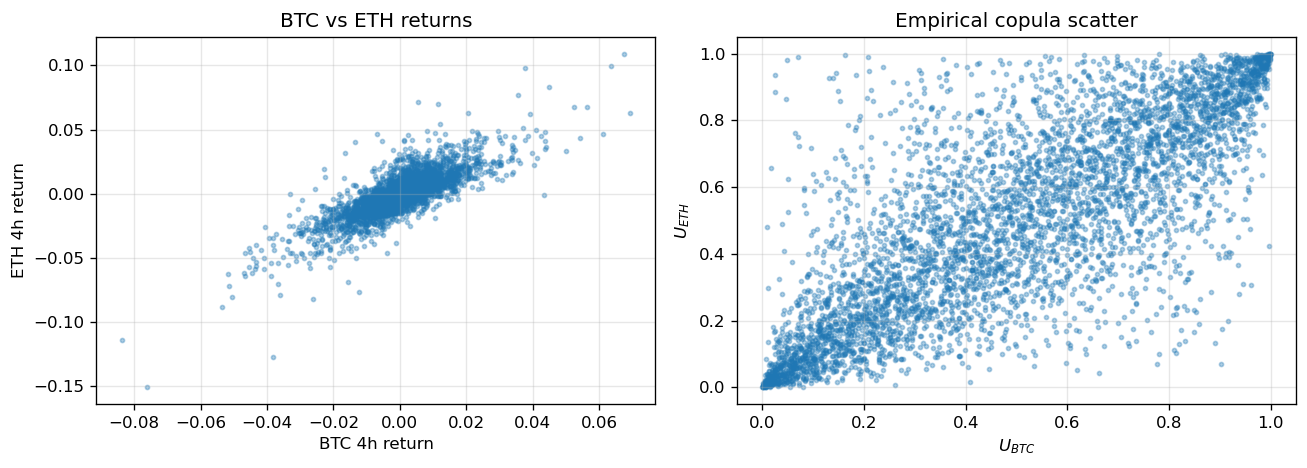

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(df["btc"], df["eth"], s=6, alpha=0.35)
axes[0].set_title("BTC vs ETH returns")
axes[0].set_xlabel("BTC 4h return")
axes[0].set_ylabel("ETH 4h return")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(u_btc, u_eth, s=6, alpha=0.35)
axes[1].set_title("Empirical copula scatter")
axes[1].set_xlabel(r"$U_{BTC}$")
axes[1].set_ylabel(r"$U_{ETH}$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### What these outputs measure

This section studies whether BTC and ETH move independently or jointly.

- **Pearson correlation** measures linear co-movement.
- **Spearman** and **Kendall tau** measure rank-based dependence and are less sensitive to outliers.
- **Gaussian-copula rho** measures dependence after a rank-to-normal transform.

### What the current output says

- Pearson correlation: **0.812**
- Spearman correlation: **0.783**
- Kendall tau: **0.605**
- Gaussian-copula rho: **0.804**

These are all high and positive.

### Interpretation

BTC and ETH are not moving independently.  
Instead, they share a very strong common market component.

The raw-return scatter plot shows a tight upward-sloping cloud.  
The copula scatter shows that this dependence is not only a linear effect but also remains strong after rank transformation.

### Practical meaning

This has two important implications:

1. Holding BTC and ETH together gives **some** diversification, but not much during normal conditions because they are strongly linked.
2. Any factor model or PCA on this dataset should naturally reveal a **dominant first common factor**.


## 7. Empirical tail co-movement

In [8]:

def conditional_coexceed(u, v, q):
    lower = np.mean(v[u < q] < q) if np.any(u < q) else np.nan
    upper = np.mean(v[u > 1-q] > 1-q) if np.any(u > 1-q) else np.nan
    return lower, upper

tail5 = conditional_coexceed(u_btc, u_eth, 0.05)
tail1 = conditional_coexceed(u_btc, u_eth, 0.01)

tail_dep = pd.DataFrame({
    "Level": ["5%", "1%"],
    "Lower-tail co-movement": [tail5[0], tail1[0]],
    "Upper-tail co-movement": [tail5[1], tail1[1]],
})

tail_dep


,Level,Lower-tail co-movement,Upper-tail co-movement
0,5%,0.641975,0.497942
1,1%,0.604167,0.437500



### What this table does

This is a simple empirical way to check whether BTC and ETH tend to crash together more strongly than they boom together.

For example, at the 5% level:

- **Lower-tail co-movement** asks:  
  if BTC is already in its worst 5% of returns, how often is ETH also in its worst 5%?
- **Upper-tail co-movement** asks:  
  if BTC is in its best 5% of returns, how often is ETH also in its best 5%?

### Current result

- At the **5%** level:
  - lower-tail co-movement = **0.642**
  - upper-tail co-movement = **0.498**
- At the **1%** level:
  - lower-tail co-movement = **0.604**
  - upper-tail co-movement = **0.438**

### Interpretation

The lower-tail co-movement is stronger than the upper-tail co-movement.  
So BTC and ETH are more likely to move together in extreme downside episodes than in equally extreme upside episodes.

### Why this matters

This is a very useful risk-management finding:

- correlation alone can miss asymmetry,
- but this table shows that downside dependence is particularly important.

So even if a portfolio contains both BTC and ETH, diversification may weaken exactly when the market is under stress.


## 8. Regression-based factor view



A natural choice for this dataset is:

$$
R_t^{ETH} = \alpha + \beta R_t^{BTC} + \varepsilon_t.
$$

This treats BTC as the factor-like regressor and ETH as the response.


In [9]:
ols, ols_hac = ols_fit_with_optional_hac(df["eth"], df["btc"], hac_lags=6, regressor_name="btc")

coef_table = pd.DataFrame({
    "OLS coefficient": ols.params,
    "OLS std.err": ols.bse,
    "HAC std.err": ols_hac.bse,
    "HAC t/z-stat": ols_hac.tvalues,
    "HAC p-value": ols_hac.pvalues,
})

coef_table


,OLS coefficient,OLS std.err,HAC std.err,HAC t/z-stat,HAC p-value
const,-0.000131,0.000122,0.000124,-1.053313,0.292198
btc,1.145119,0.011804,0.023748,48.220240,0.000000


,Quantity,Value
0,beta from covariance formula,1.145119e+00
1,beta from OLS,1.145119e+00
2,"Cov(residual, BTC)",6.215498e-20
3,Var(residual),7.243102e-05
4,R^2 from OLS,6.592520e-01
5,squared correlation,6.592520e-01


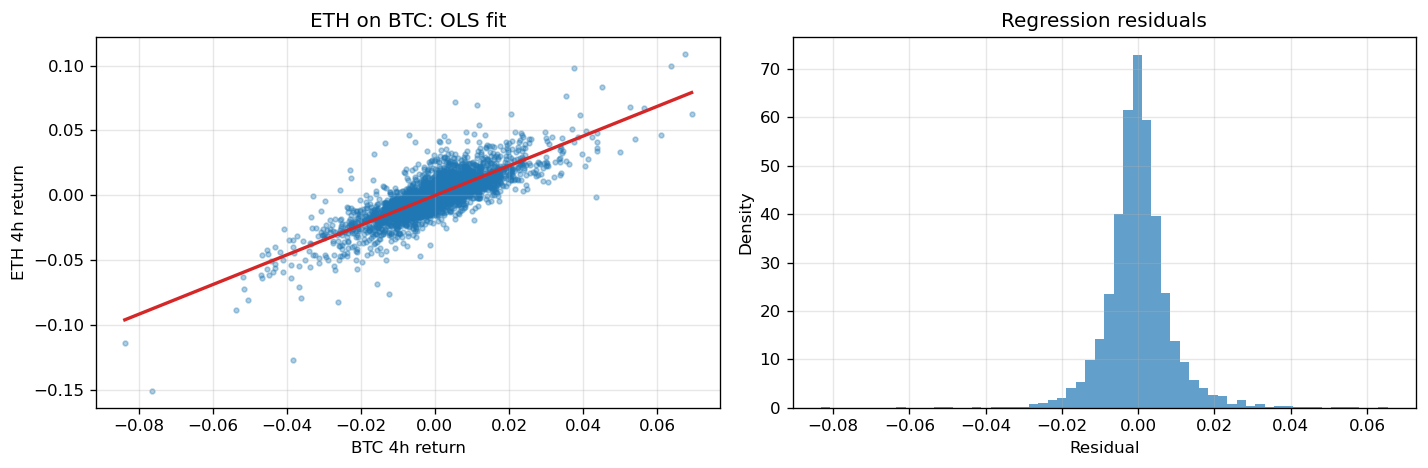

In [10]:

beta_cov = df["eth"].cov(df["btc"]) / df["btc"].var(ddof=1)
r2_from_corr = df["eth"].corr(df["btc"]) ** 2
resid = ols.resid

check_table = pd.DataFrame({
    "Quantity": [
        "beta from covariance formula",
        "beta from OLS",
        "Cov(residual, BTC)",
        "Var(residual)",
        "R^2 from OLS",
        "squared correlation"
    ],
    "Value": [
        beta_cov,
        ols.params["btc"],
        np.cov(resid, df["btc"], ddof=1)[0,1],
        np.var(resid, ddof=1),
        ols.rsquared,
        r2_from_corr,
    ],
})

display(check_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["btc"], df["eth"], s=8, alpha=0.35)
xgrid = np.linspace(df["btc"].min(), df["btc"].max(), 200)
axes[0].plot(xgrid, ols.params["const"] + ols.params["btc"] * xgrid, lw=2, color="tab:red")
axes[0].set_title("ETH on BTC: OLS fit")
axes[0].set_xlabel("BTC 4h return")
axes[0].set_ylabel("ETH 4h return")
axes[0].grid(True, alpha=0.3)

axes[1].hist(resid, bins=60, density=True, alpha=0.7)
axes[1].set_title("Regression residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Density")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### Detailed interpretation of the regression output

#### 1. Intercept and slope
The fitted regression is approximately

$$
R_t^{ETH} = -0.000131 + 1.145 \, R_t^{BTC} + \varepsilon_t.
$$

- The intercept is close to zero and statistically insignificant.
- The slope is about **1.145**, clearly above 1.

This means that, on average, ETH reacts **more strongly** than BTC at the same 4-hour horizon.

#### 2. Robust significance
The HAC-robust standard error is included because crypto returns may show mild serial dependence or heteroskedasticity.  
Even with HAC adjustment, the BTC loading remains extremely significant.

#### 3. Orthogonality check
The table confirms that

$$
\operatorname{Cov}(\hat\varepsilon, R^{BTC}) \approx 0,
$$

which is exactly what the OLS orthogonality theorem predicts.

#### 4. Explanatory power
The regression $R^2$ is about **0.659**, meaning BTC alone explains roughly **65.9%** of ETH's 4-hour return variation.

That is a strong result for a one-factor regression.

#### 5. Economic meaning
This section gives an empirical version of the systematic–idiosyncratic decomposition:

- the fitted part corresponds to **common crypto-market movement**,
- the residual corresponds to **ETH-specific variation** after removing BTC co-movement.



## 9. Assignment 3 empirical part: PCA and common-factor structure

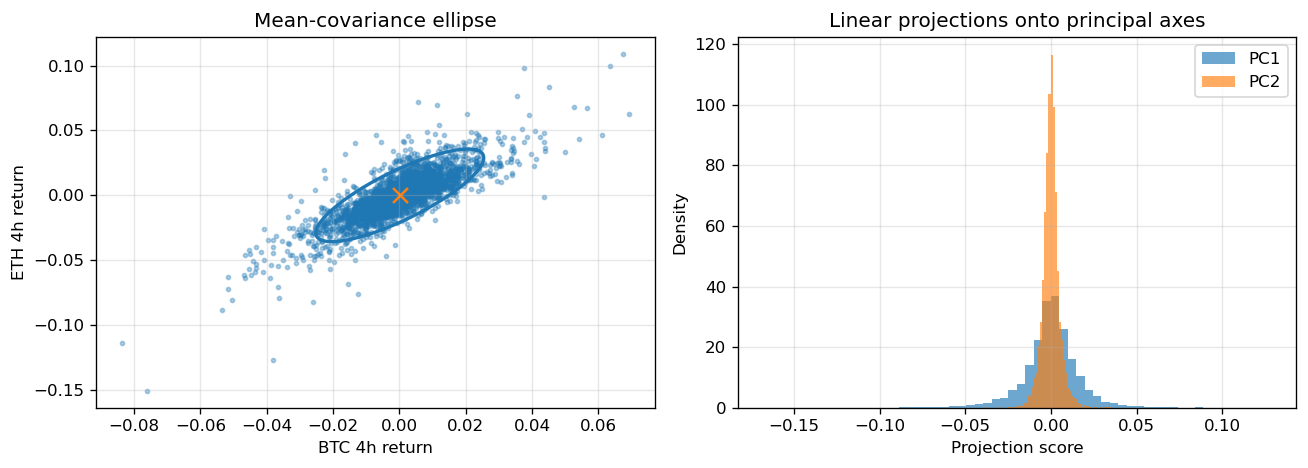

,eigenvalue,explained_variance_ratio
PC1,0.000293,0.917301
PC2,0.000026,0.082699


In [11]:

# Original mean-covariance / ellipse view
mean_xy = df[["btc", "eth"]].mean().to_numpy()
cov_xy = df[["btc", "eth"]].cov().to_numpy()

eigvals, eigvecs = eigh(cov_xy)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]
explained = eigvals / eigvals.sum()

theta = np.linspace(0, 2*np.pi, 400)
circle = np.vstack((np.cos(theta), np.sin(theta)))
c95 = chi2.ppf(0.95, df=2)
ellipse = mean_xy.reshape(2,1) + eigvecs @ np.diag(np.sqrt(c95 * eigvals)) @ circle

pc_scores_cov = (df[["btc", "eth"]].to_numpy() - mean_xy) @ eigvecs

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(df["btc"], df["eth"], s=6, alpha=0.35)
axes[0].plot(ellipse[0], ellipse[1], lw=2)
axes[0].scatter(mean_xy[0], mean_xy[1], marker="x", s=80)
axes[0].set_title("Mean-covariance ellipse")
axes[0].set_xlabel("BTC 4h return")
axes[0].set_ylabel("ETH 4h return")
axes[0].grid(True, alpha=0.3)

axes[1].hist(pc_scores_cov[:,0], bins=60, density=True, alpha=0.65, label="PC1")
axes[1].hist(pc_scores_cov[:,1], bins=60, density=True, alpha=0.65, label="PC2")
axes[1].set_title("Linear projections onto principal axes")
axes[1].set_xlabel("Projection score")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pd.DataFrame({
    "eigenvalue": eigvals,
    "explained_variance_ratio": explained,
}, index=["PC1", "PC2"])


,eigenvalue,explained_variance_ratio
PC1,1.812316,0.905972
PC2,0.188095,0.094028


,PC1,PC2
BTC,-0.707107,0.707107
ETH,-0.707107,-0.707107


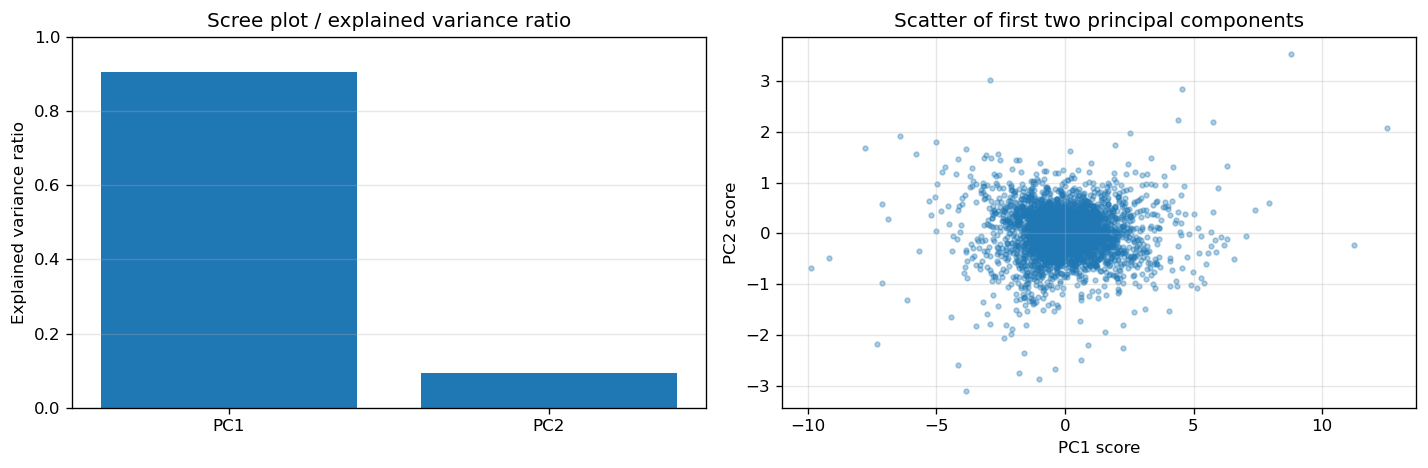

In [12]:

# Standardized PCA
Xraw = df[["btc", "eth"]].to_numpy()
scaler = StandardScaler(with_mean=True, with_std=True)
Xstd = scaler.fit_transform(Xraw)

pca = PCA(n_components=2)
scores = pca.fit_transform(Xstd)
loadings = pd.DataFrame(
    pca.components_.T,
    index=["BTC", "ETH"],
    columns=["PC1", "PC2"]
)

pca_summary = pd.DataFrame({
    "eigenvalue": pca.explained_variance_,
    "explained_variance_ratio": pca.explained_variance_ratio_,
}, index=["PC1", "PC2"])

display(pca_summary)
display(loadings)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["PC1", "PC2"], pca.explained_variance_ratio_)
axes[0].set_ylim(0, 1)
axes[0].set_title("Scree plot / explained variance ratio")
axes[0].set_ylabel("Explained variance ratio")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].scatter(scores[:, 0], scores[:, 1], s=8, alpha=0.35)
axes[1].set_title("Scatter of first two principal components")
axes[1].set_xlabel("PC1 score")
axes[1].set_ylabel("PC2 score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### How to interpret these PCA outputs

PCA asks whether most of the joint movement of BTC and ETH can be summarized by a small number of latent directions.

#### 1. Covariance-PCA result
Using the raw covariance matrix, the first principal component explains about **91.7%** of the total joint variance.

#### 2. Standardized-PCA result
After standardizing the two series, PC1 still explains about **90.6%** of the total standardized variance.

So regardless of scaling choice, the conclusion is the same:  
**one dominant common factor drives most BTC/ETH co-movement.**

#### 3. Loadings
The loading table usually shows that PC1 loads positively on both BTC and ETH.  
That means PC1 represents the **shared market direction**.

PC2 typically loads with opposite signs, so it captures a **relative-movement / spread dimension**:
- when PC2 rises, one asset is outperforming the other.

#### 4. Why PCA is useful here

- regression gives a **supervised one-factor view** (ETH explained by BTC),
- PCA gives an **unsupervised common-factor view**.

Both methods tell the same story for the dataset:
BTC and ETH are largely driven by a common market component.


## 10. Decision and estimation perspective


### 10.1 Statistical decision framing for this dataset

A natural decision problem for these data is a **one-step portfolio choice** between BTC and ETH.

At time $t$, choose a BTC weight $a_t \in [0,1]$, and put the remaining weight $1-a_t$ in ETH.  
The next 4-hour portfolio return is

$$
R^p_{t+1}(a_t) = a_t R^{BTC}_{t+1} + (1-a_t) R^{ETH}_{t+1}.
$$

A simple risk-adjusted loss is

$$
L(a_t, R_{t+1})
=
- R^p_{t+1}(a_t)
+ \frac{\gamma}{2} \operatorname{Var}(R^p_{t+1}(a_t)),
$$

where $\gamma > 0$ controls risk aversion.

### Why this is relevant

This takes the raw dataset and translates it into the language of **statistical decision theory**:

- the **action** is the portfolio weight,
- the **state of nature** is the next-period BTC/ETH return vector,
- the **loss** balances reward and risk.


The dataset provides the empirical return distribution needed to define and solve the decision problem.



### 10.1A The same decision problem under three perspectives

The notebook originally translated the dataset into a **mean-variance portfolio choice** problem, but we wanat to asks for the problem to be viewed from **Frequentist, Bayesian, and Interventional** perspectives.  
The three perspectives are related, but they are not identical.

#### Frequentist perspective
Treat the BTC/ETH return vectors
$$
R_t = (R_t^{BTC}, R_t^{ETH})^\top
$$
as i.i.d. draws from an unknown distribution with parameters
$$
\mu = \mathbb{E}[R_t], \qquad \Sigma = \operatorname{Cov}(R_t).
$$
The decision problem is:

1. estimate $(\mu,\Sigma)$ from the sample;
2. plug those estimates into the risk-adjusted objective;
3. choose the portfolio weight $a$ that minimizes estimated risk (or maximizes estimated certainty equivalent).

So the **uncertainty** is about the unknown population moments, while the action rule is a plug-in decision rule based on sample estimates.

#### Bayesian perspective
Treat $(\mu,\Sigma)$ as unknown random objects with a prior distribution.  
After observing the BTC/ETH data, update the prior into a posterior (or posterior predictive) distribution.  
Then choose the weight $a$ by minimizing the **posterior expected loss**:
$$
a^{Bayes}
=
\arg\min_a \; \mathbb{E}\!\left[L(a,R_{t+1}) \mid \text{data}\right].
$$

In this notebook, the **Black-Litterman illustration** plays the role of a Bayesian-style update:
- the equilibrium prior represents structured prior information,
- the views represent subjective information,
- the posterior mean represents the updated expected return.

So the Bayesian perspective emphasizes **learning + shrinkage + posterior decision-making**.

#### Interventional perspective
The interventional view asks:
> What happens to the next portfolio payoff if we actively set the BTC weight to a chosen value $a$?

Using Pearl's notation, we can define the potential / interventional portfolio outcome as
$$
Y_{t+1}(a) = a R^{BTC}_{t+1} + (1-a) R^{ETH}_{t+1}.
$$

Then the object of interest becomes the distribution of
$$
Y_{t+1}(a) \mid do(a).
$$

In this simple portfolio-allocation setting, the intervention changes the **portfolio composition**, not the asset returns themselves.  
Under the classroom assumption of **no market impact** (our trade does not move BTC/ETH returns), the intervention is well-defined and can be evaluated from the observed return sample.




In [13]:

# 10.1B Numerical illustration of the three perspectives on the portfolio-weight choice

gamma = 3.0
weight_grid = np.linspace(0.0, 1.0, 101)

mu_freq = df[["btc", "eth"]].mean().to_numpy()
Sigma_freq = df[["btc", "eth"]].cov().to_numpy()

def certainty_equivalent(mu_vec, Sigma_mat, a, gamma=3.0):
    w = np.array([a, 1.0 - a])
    return float(w @ mu_vec - 0.5 * gamma * (w @ Sigma_mat @ w))

# Frequentist plug-in certainty equivalent
ce_freq = np.array([certainty_equivalent(mu_freq, Sigma_freq, a, gamma) for a in weight_grid])

# Interventional / empirical evaluation under do(a): compute realized portfolio moments directly
port_mean_emp = []
port_var_emp = []
ce_do = []
for a in weight_grid:
    rp = a * df["btc"].to_numpy() + (1.0 - a) * df["eth"].to_numpy()
    m = rp.mean()
    v = rp.var(ddof=1)
    port_mean_emp.append(m)
    port_var_emp.append(v)
    ce_do.append(m - 0.5 * gamma * v)

decision_table = pd.DataFrame({
    "a_BTC": weight_grid,
    "CE_frequentist_plugin": ce_freq,
    "CE_interventional_empirical": ce_do,
    "mean_do(a)": port_mean_emp,
    "var_do(a)": port_var_emp,
})

decision_table.loc[[decision_table["CE_frequentist_plugin"].idxmax(),
                    decision_table["CE_interventional_empirical"].idxmax()]]


,a_BTC,CE_frequentist_plugin,CE_interventional_empirical,mean_do(a),var_do(a)
100,1.0,-0.000059,-0.000059,0.000101,0.000107
100,1.0,-0.000059,-0.000059,0.000101,0.000107



### 10.1C How to read the decision table

The table reports two numerically very similar decision summaries:

1. **Frequentist plug-in certainty equivalent**  
   uses the sample estimates $(\hat\mu,\hat\Sigma)$ and plugs them into the mean-variance objective;

2. **Interventional empirical certainty equivalent**  
   directly computes the realized portfolio return series under the action $do(a)$ and then evaluates its sample mean and variance.

In this particular two-asset linear setting, the two are almost the same because both rely on the same empirical first and second moments.  
This is actually a useful point:

- the **Frequentist** view emphasizes *parameter estimation* first and *decision* second;
- the **Interventional** view emphasizes the *counterfactual action* $do(a)$ and the resulting payoff distribution.

So even when the numbers line up, the **interpretation is different**.


In [14]:

mu_hat = df[["btc", "eth"]].mean()
Sigma_hat = df[["btc", "eth"]].cov()

display(mu_hat.to_frame(name="sample mean"))
display(Sigma_hat)


,sample mean
btc,0.000101
eth,-0.000015


,btc,eth
btc,0.000107,0.000122
eth,0.000122,0.000213



### 10.2 Detailed explanation of the estimation output

This section estimates the two most basic objects needed for decision-making:

1. the mean vector
$$
\hat\mu = (\hat\mu_{BTC}, \hat\mu_{ETH})^\top,
$$
2. the covariance matrix
$$
\hat\Sigma.
$$

### What the current output says

- The sample mean of BTC is approximately **0.000101** per 4 hours.
- The sample mean of ETH is approximately **-0.000015** per 4 hours.
- The covariance matrix shows:
  - BTC has lower variance,
  - ETH has higher variance,
  - the off-diagonal covariance is positive and large.

### Why this matters

These two estimates are exactly the empirical inputs used in many decision procedures:

- mean-variance portfolio choice,
- Bayesian return modeling,
- Black-Litterman style posterior updating,
- and risk decomposition.




### 10.2A Estimation problem under Frequentist, Bayesian, and M-estimation frameworks

We want to asks for the **estimation problem** to be framed under different statistical traditions.  
For this BTC/ETH dataset, the natural estimation problem is:

> estimate the return location and dependence structure needed for portfolio choice.

More concretely, we want to estimate:
- the mean vector $\mu$,
- the covariance matrix $\Sigma$,
- and, because the data are heavy-tailed, possibly a **robust alternative** to the raw sample mean.

#### Frequentist framework
The standard Frequentist estimators are the sample mean and the sample covariance:
$$
\hat\mu = \frac{1}{n}\sum_{t=1}^n R_t,
\qquad
\hat\Sigma = \frac{1}{n-1}\sum_{t=1}^n (R_t-\hat\mu)(R_t-\hat\mu)^\top.
$$

This is exactly what the notebook already computed.  
It is simple and natural, but it can be sensitive to outliers and heavy tails.

#### Bayesian framework
In a Bayesian framework, one places a prior on $(\mu,\Sigma)$ and updates that prior after observing the sample.  
The key output is not just a point estimate, but a posterior (or posterior predictive) distribution.

In this notebook, the **Black-Litterman posterior mean** serves as a Bayesian-style mean estimator:
- prior information comes from equilibrium structure,
- the views inject additional information,
- the posterior mean shrinks noisy sample means toward a more structured prior.

So the Bayesian framework is especially attractive when the raw sample means are unstable.

#### M-estimation / robust framework
Because BTC and ETH returns are clearly non-Gaussian and heavy-tailed, it is reasonable to consider a **robust location estimator** that downweights extreme observations.

A standard idea is Huber-type M-estimation, which solves
$$
\hat\theta_M = \arg\min_\theta \sum_{t=1}^n \rho\!\left(\frac{R_t-\theta}{s}\right),
$$
for a robust loss $\rho$ and scale $s$.

The practical purpose is:
- keep central observations influential,
- reduce the leverage of extreme returns,
- produce a more stable center estimate when tails are heavy.

Below, we compute a simple Huber-style robust location estimate for BTC and ETH as an empirical complement to the sample mean.


In [15]:

# 10.2B Robust (Huber-style) location estimate as an M-estimation illustration

def huber_location(x, c=1.345, tol=1e-10, max_iter=200):
    x = np.asarray(x, dtype=float)
    theta = np.median(x)
    mad = np.median(np.abs(x - theta))
    s = mad / 0.67448975 if mad > 0 else x.std(ddof=1)
    s = max(float(s), 1e-8)

    for _ in range(max_iter):
        r = (x - theta) / s
        w = np.ones_like(r)
        mask = np.abs(r) > c
        w[mask] = c / np.abs(r[mask])
        theta_new = np.sum(w * x) / np.sum(w)
        if abs(theta_new - theta) < tol:
            break
        theta = theta_new
    return float(theta)

robust_table = pd.DataFrame({
    "sample_mean": df[["btc", "eth"]].mean(),
    "median": df[["btc", "eth"]].median(),
    "huber_M_location": pd.Series({
        "btc": huber_location(df["btc"]),
        "eth": huber_location(df["eth"]),
    })
})
robust_table


,sample_mean,median,huber_M_location
btc,0.000101,0.000213,0.000236
eth,-0.000015,0.000168,0.000226



### 10.2C How to interpret the robust-estimation output

This table compares three center estimators for each asset:

1. **sample mean**: the standard Frequentist estimator;
2. **median**: a very robust but less efficient estimator under Gaussian data;
3. **Huber M-location**: a compromise between mean and median.

#### What the comparison tells us
- If the sample mean and Huber estimate are very close, the center estimate is relatively stable.
- If they differ visibly, the raw sample mean may be influenced by extreme observations.
- Because the earlier diagnostics showed **heavy tails and non-Gaussianity**, including a robust estimator strengthens the report conceptually.

So after this addition, the notebook now covers:
- **Frequentist estimation** through sample moments,
- **Bayesian-style estimation** through Black-Litterman posterior updating,
- **M-estimation** through robust location estimation.



### 10.3 Black-Litterman illustration

The uploaded dataset contains returns but not true market capitalizations, so the Black-Litterman step below is only a **classroom illustration**, not a production portfolio model.

We use:

- sample covariance estimated from the BTC/ETH 4-hour returns,
- proxy market weights $w^{mkt}=(0.75, 0.25)^\top$,
- risk aversion $\delta=3$,
- prior scale $\tau=0.05$.

Two illustrative views are imposed:

1. BTC is expected to outperform ETH by roughly 1.5 basis points per 4 hours,  
2. ETH itself is still expected to have a slightly positive mean return.

The purpose is to show how **equilibrium information + subjective views** can be blended into a posterior return estimate.


In [16]:

returns = df[["btc", "eth"]]
Sigma = returns.cov().to_numpy()

delta = 3.0
w_mkt = np.array([0.75, 0.25])
Pi = delta * Sigma @ w_mkt

tau = 0.05
P = np.array([
    [1.0, -1.0],   # BTC minus ETH view
    [0.0,  1.0],   # ETH absolute-return view
])
Q = np.array([0.00015, 0.00002])

Omega = np.diag(np.diag(P @ (tau * Sigma) @ P.T))
posterior_cov_mu = np.linalg.inv(np.linalg.inv(tau * Sigma) + P.T @ np.linalg.inv(Omega) @ P)
mu_bl = posterior_cov_mu @ (np.linalg.inv(tau * Sigma) @ Pi + P.T @ np.linalg.inv(Omega) @ Q)

bl_table = pd.DataFrame({
    "Equilibrium prior Π": Pi,
    "Sample mean": returns.mean().to_numpy(),
    "BL posterior mean": mu_bl,
}, index=["BTC", "ETH"])

bl_table


,Equilibrium prior Π,Sample mean,BL posterior mean
BTC,0.000332,0.000101,0.000226
ETH,0.000435,-0.000015,0.000170



### 10.4 Detailed explanation of the Black-Litterman output

This table compares three mean-return objects:

1. **Equilibrium prior Π**  
   implied by covariance + market-weight proxy,
2. **Sample mean**  
   directly estimated from the data,
3. **BL posterior mean**  
   obtained after blending the prior with subjective views.

### How to interpret the current output

- The sample means are noisy and very close to zero, especially for ETH.
- The equilibrium prior is more structured because it is generated from covariance information and the proxy market portfolio.
- The BL posterior lies between pure equilibrium and pure sample estimation.

### Why this is useful

The practical message is not that the exact BL numbers are “true.”  
Rather, the example shows that when raw sample means are unstable, Black-Litterman offers a disciplined way to **shrink** noisy estimates toward a more structured prior while still incorporating views.




## 11. Integrated conclusion: what has been done to the dataset and what has been learned

### What was done

Starting from the two uploaded merged CSV files, the analysis:

1. aligned BTC and ETH 4-hour returns by timestamp,  
2. summarized their distributional properties,  
3. checked Gaussianity using density plots, tail probabilities, and Q-Q plots,  
4. measured cross-asset dependence using correlation and copula-style diagnostics,  
5. examined downside co-movement,  
6. ran an ETH-on-BTC regression to obtain a factor loading and residual structure,  
7. ran PCA to detect common latent factors,  
8. translated the dataset into Assignment 2's decision / estimation language,  
9. explicitly framed the same portfolio problem under Frequentist, Bayesian, and Interventional perspectives,  
10. compared Frequentist sample-moment estimation with a robust M-estimation illustration, and  
11. illustrated Black-Litterman as a structured posterior-return update.

### Main empirical findings

- Both BTC and ETH are **non-Gaussian** at the 4-hour horizon.
- ETH is **more volatile, more negatively skewed, and more heavy-tailed** than BTC.
- BTC and ETH show **strong positive dependence**.
- Downside co-movement is stronger than upside co-movement.
- In regression, BTC explains a large share of ETH variation.
- In PCA, the first principal component dominates total variance.
- From a decision-theoretic perspective, the key empirical inputs are the estimated mean vector and covariance matrix.
- From a Bayesian / probabilistic perspective, Black-Litterman provides a structured way to combine prior equilibrium information with subjective views.

### Overall interpretation

This dataset is a strong empirical example of the standard financial-return stylized facts and of the common-factor structure in crypto markets.  

### Next step


- rolling-window estimation,
- conditional volatility models,
- more assets or market factors,
- or a predictive / decision model built on the same BTC/ETH state variables.
